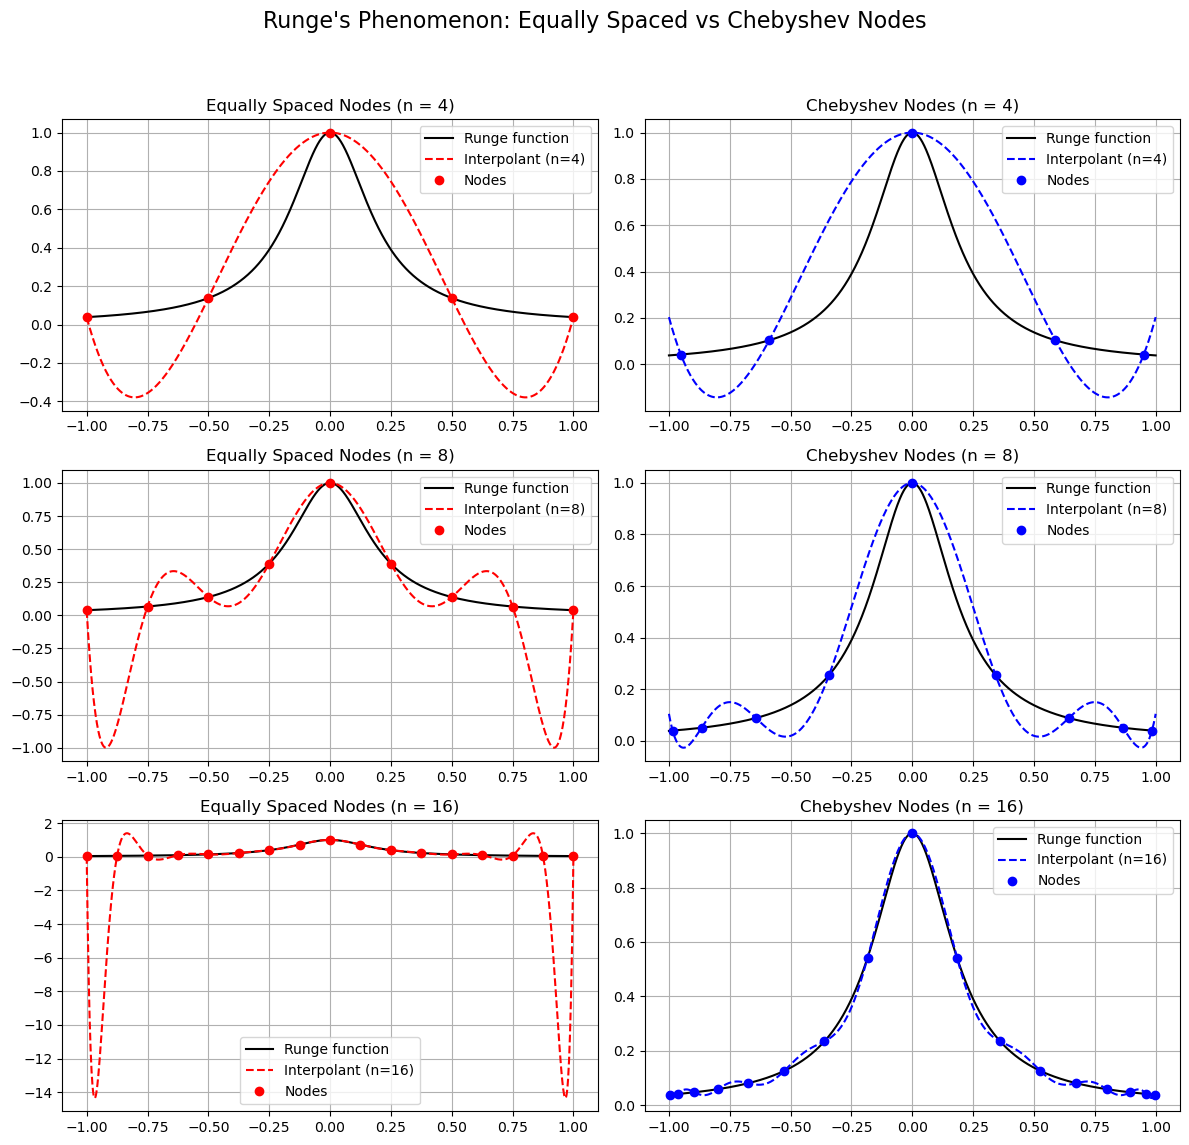

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
from scipy.interpolate import BarycentricInterpolator

# Define the Runge function
def runge_function(x):
    return 1 / (1 + 25 * x**2)

# Generate equally spaced nodes
def equally_spaced_nodes(a, b, n):
    return np.linspace(a, b, n + 1)

# Generate Chebyshev nodes
def chebyshev_nodes(a, b, n):
    i = np.arange(n + 1)
    x_cheb = np.cos((2*i + 1) * np.pi / (2*(n + 1)))
    return 0.5*(a + b) + 0.5*(b - a)*x_cheb

# Interpolate and return function values
def interpolate_and_evaluate(x_nodes, y_nodes, x_eval):
    interpolator = BarycentricInterpolator(x_nodes, y_nodes)
    return interpolator(x_eval)

# Main plotting function
def plot_runge_interpolation(n_values, a=-1, b=1):
    x_plot = np.linspace(a, b, 1000)
    y_true = runge_function(x_plot)

    fig, axs = plt.subplots(len(n_values), 2, figsize=(12, 4 * len(n_values)))
    fig.suptitle("Runge's Phenomenon: Equally Spaced vs Chebyshev Nodes", fontsize=16)

    for idx, n in enumerate(n_values):
        # Equally spaced nodes
        x_eq = equally_spaced_nodes(a, b, n)
        y_eq = runge_function(x_eq)
        y_interp_eq = interpolate_and_evaluate(x_eq, y_eq, x_plot)

        # Chebyshev nodes
        x_cheb = chebyshev_nodes(a, b, n)
        y_cheb = runge_function(x_cheb)
        y_interp_cheb = interpolate_and_evaluate(x_cheb, y_cheb, x_plot)

        # Plotting
        axs[idx, 0].plot(x_plot, y_true, 'k-', label='Runge function')
        axs[idx, 0].plot(x_plot, y_interp_eq, 'r--', label=f'Interpolant (n={n})')
        axs[idx, 0].plot(x_eq, y_eq, 'ro', label='Nodes')
        axs[idx, 0].set_title(f'Equally Spaced Nodes (n = {n})')
        axs[idx, 0].legend()
        axs[idx, 0].grid(True)

        axs[idx, 1].plot(x_plot, y_true, 'k-', label='Runge function')
        axs[idx, 1].plot(x_plot, y_interp_cheb, 'b--', label=f'Interpolant (n={n})')
        axs[idx, 1].plot(x_cheb, y_cheb, 'bo', label='Nodes')
        axs[idx, 1].set_title(f'Chebyshev Nodes (n = {n})')
        axs[idx, 1].legend()
        axs[idx, 1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Try it with degrees 4, 8, and 16
plot_runge_interpolation(n_values=[4, 8, 16])
